# Evaluation: Burgers Super-Resolution

Zero-shot super-resolution: model trained on **2048-pt** grid (`subsample=4`), evaluated on **8192-pt** grid (`subsample=1`).

Mirrors `galerkin-transformer/eval/ex1_burgers_eval.ipynb`.

In [23]:
import sys
import os
import glob

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

sys.path.insert(0, os.path.abspath('.'))
from model import SimpleTransformer
from utils import (
    BurgersDataset,
    WeightedL2Loss,
    validate_epoch_burgers,
    get_num_params,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## Config

In [24]:
DEFAULT_CONFIG = dict(
    node_feats=1,
    edge_feats=None,
    pos_dim=1,
    n_targets=1,
    n_hidden=92,
    num_feat_layers=0,
    num_encoder_layers=4,
    n_head=1,
    pred_len=0,
    n_freq_targets=0,
    dim_feedforward=200,
    feat_extract_type=None,
    attention_type='functional',
    xavier_init=0.001,
    diagonal_weight=0.01,
    symmetric_init=False,
    layer_norm=False,
    attn_norm=True,
    batch_norm=False,
    spacial_residual=False,
    return_attn_weight=False,
    return_latent=False,
    residual_type='plus',
    seq_len=None,
    bulk_regression=False,
    decoder_type='ifft',
    freq_dim=48,
    num_regressor_layers=2,
    fourier_modes=16,
    spacial_dim=1,
    dropout=0.0,
    encoder_dropout=0.0,
    ffn_dropout=0.0,
    decoder_dropout=0.0,
)

## Paths

In [25]:
DATA_PATH  = './burgers_data_R10.mat'
MODEL_DIR  = './models'

# pick the latest checkpoint automatically, or hard-code a specific one
checkpoints = sorted(glob.glob(os.path.join(MODEL_DIR, 'burgers_super_res_*.pt')))
MODEL_PATH  = checkpoints[-1]
print('Using checkpoint:', MODEL_PATH)

Using checkpoint: ./models/burgers_super_res_2026-04-21.pt


## Part 1 — Training-resolution validation (subsample = 4, n = 2048)

In [26]:
subsample_train = 4
val_batch_size  = 4

valid_dataset_2048 = BurgersDataset(
    subsample=subsample_train,
    train_data=False,
    valid_portion=100,
    data_path=DATA_PATH,
)
valid_loader_2048 = DataLoader(
    valid_dataset_2048, batch_size=val_batch_size,
    shuffle=False, drop_last=False, pin_memory=(device.type == 'cuda'),
)
print(f'Val samples (2048-pt): {len(valid_dataset_2048)}')

Val samples (2048-pt): 100


In [27]:
config = dict(DEFAULT_CONFIG)
torch.cuda.empty_cache()
model = SimpleTransformer(**config).to(device)
print(f'Model params: {get_num_params(model):,}')

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

h_train  = (1 / 8192) * subsample_train
metric_func_2048 = WeightedL2Loss(regularizer=False, h=h_train)

val_result_2048 = validate_epoch_burgers(model, metric_func_2048, valid_loader_2048, device)
print(f'\nValidation metric @ 2048 pts: {val_result_2048["metric"]:.4e}')

Model params: 600,241

Validation metric @ 2048 pts: 1.0747e-03


## Part 2 — Zero-shot super-resolution (subsample = 1, n = 8192)

In [28]:
subsample_fine = 1

valid_dataset_8192 = BurgersDataset(
    subsample=subsample_fine,
    train_data=False,
    valid_portion=100,
    data_path=DATA_PATH,
)
valid_loader_8192 = DataLoader(
    valid_dataset_8192, batch_size=val_batch_size,
    shuffle=False, drop_last=False, pin_memory=(device.type == 'cuda'),
)
print(f'Val samples (8192-pt): {len(valid_dataset_8192)}')

Val samples (8192-pt): 100


In [29]:
h_fine  = 1 / 8192
metric_func_8192 = WeightedL2Loss(regularizer=False, h=h_fine)

val_result_8192 = validate_epoch_burgers(model, metric_func_8192, valid_loader_8192, device)
print(f'\nZero-shot super-res metric @ 8192 pts: {val_result_8192["metric"]:.4e}')


Zero-shot super-res metric @ 8192 pts: 1.0747e-03


## Part 3 — Plot predictions

In [30]:
def plot_batch(loader, model, device, n_batches=3, title_suffix=''):
    data_iter = iter(loader)
    for _ in range(n_batches):
        sample = next(data_iter)
        node = sample['node']    # (B, n, 1)
        pos  = sample['pos']     # (B, n, 1)
        grid = sample['grid']    # (B, n_fine, 1)
        edge = sample['edge']    # (B, 1) placeholder
        u    = sample['target']  # (B, n, 2)

        with torch.no_grad():
            model.eval()
            out_dict = model(
                node.to(device), edge.to(device),
                pos.to(device),  grid.to(device),
            )

        preds = out_dict['preds'][..., 0].detach().cpu()  # (B, n_fine)
        B = node.size(0)

        fig, axes = plt.subplots(nrows=B, ncols=1, figsize=(18, 4 * B))
        if B == 1:
            axes = [axes]
        for i in range(B):
            x_coarse = pos[i, :, 0].numpy()
            x_fine   = grid[i, :, 0].numpy()
            axes[i].plot(x_coarse, node[i, :, 0].numpy(),
                         '-',  color='steelblue',  lw=1.5, label='$u_0$ (input)')
            axes[i].plot(x_coarse, u[i, :, 0].numpy(),
                         '-',  color='green',       lw=2.5, label='$u(x,t_1)$ (true)')
            axes[i].plot(x_fine,   preds[i].numpy(),
                         '--', color='crimson',     lw=2.0, label='$\\hat{u}(x)$ (pred)')
            axes[i].legend(fontsize=14)
            axes[i].set_title(f'Sample {i}  {title_suffix}', fontsize=13)
        plt.tight_layout()
        plt.show()

### Zero-shot super-resolution predictions (8192 pts)

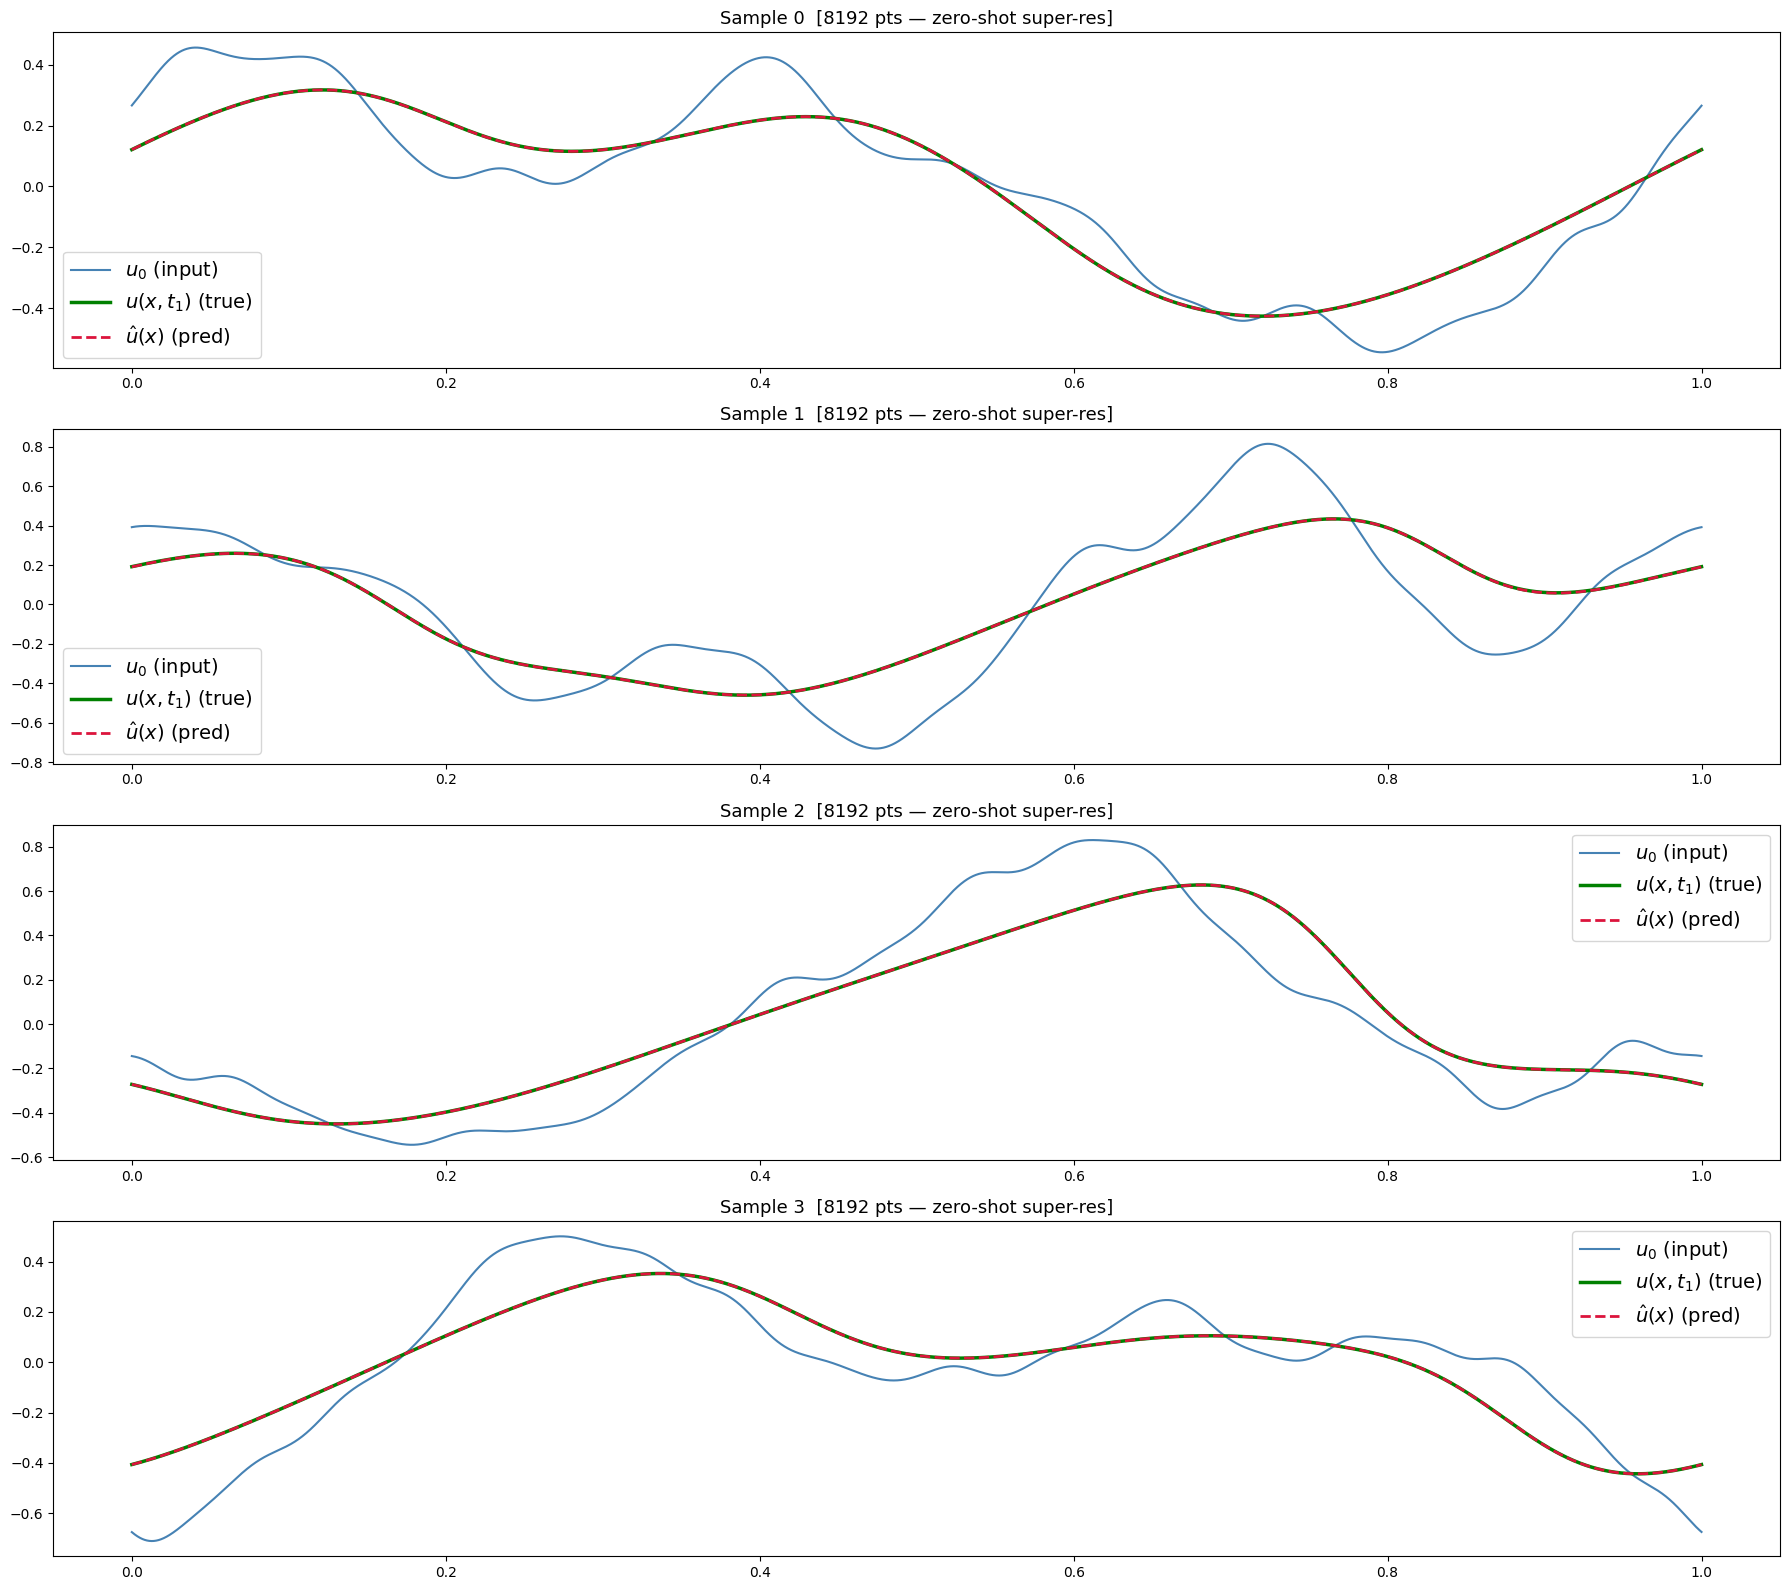

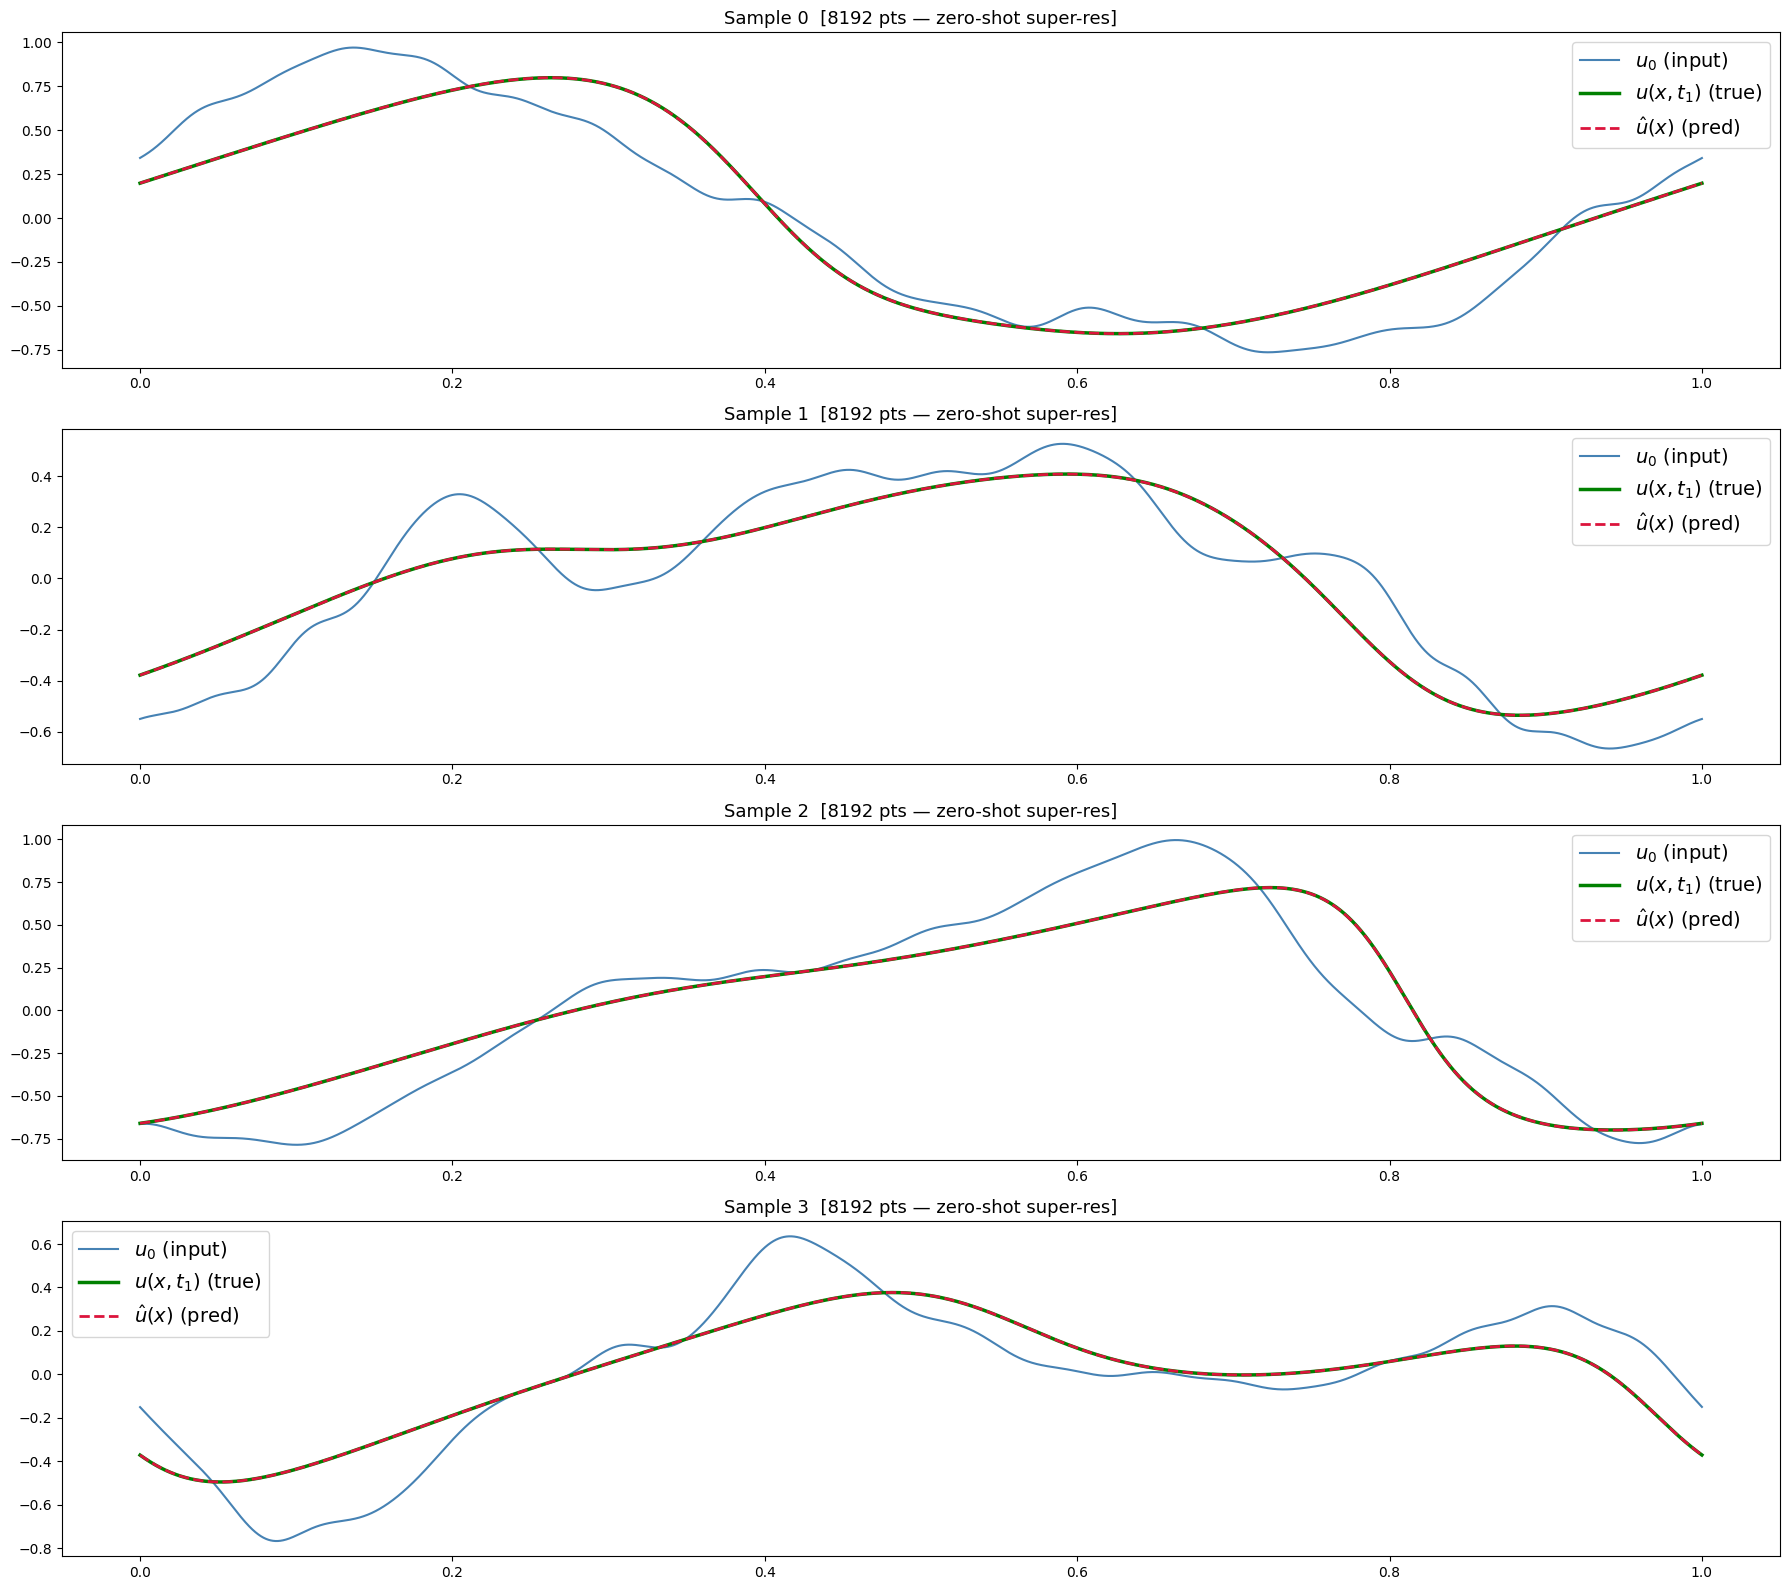

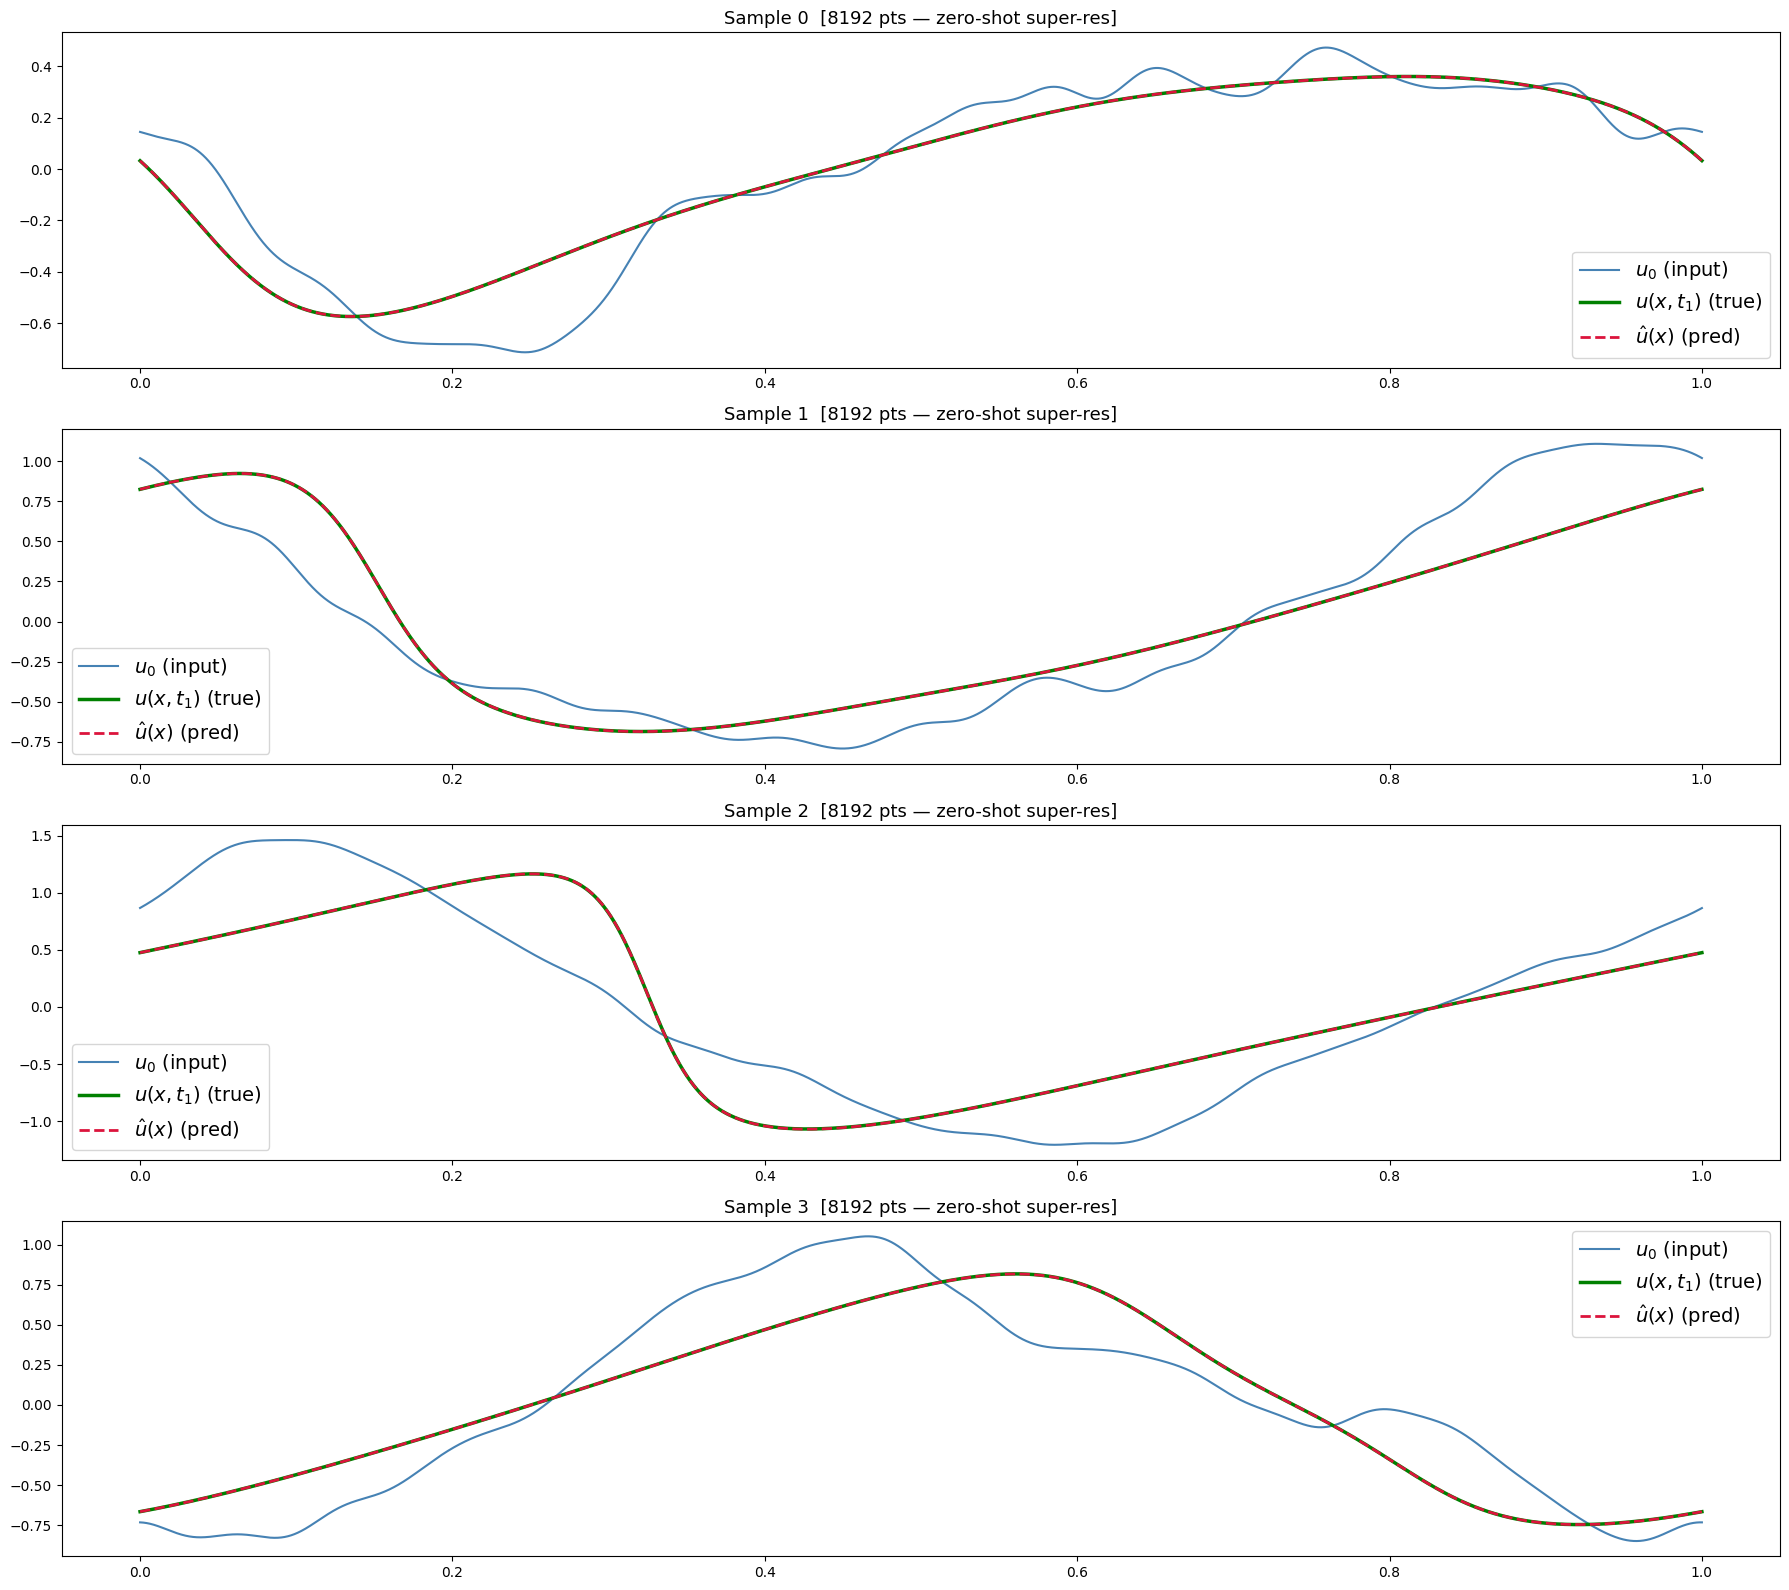

In [31]:
plot_batch(valid_loader_8192, model, device, n_batches=3, title_suffix='[8192 pts — zero-shot super-res]')

## Summary

In [32]:
print('=' * 50)
print(f'Checkpoint : {os.path.basename(MODEL_PATH)}')
print(f'Params     : {get_num_params(model):,}')
print('-' * 50)
print(f'Val metric @ 8192 pts  (super-res) : {val_result_8192["metric"]:.4e}')
print('=' * 50)

Checkpoint : burgers_super_res_2026-04-21.pt
Params     : 600,241
--------------------------------------------------
Val metric @ 8192 pts  (super-res) : 1.0747e-03
